# Tech Challenge - Fase 4: Predição de Obesidade
Pipeline completa: EDA + Feature Engineering + Treinamento de modelo de classificação multiclasse.

Alvo: Obesity (7 classes)
Dataset: Obesity.csv (~2.111 linhas, 16 features)
Meta: acurácia > 75%

In [1]:
# Descomente para instalar dependências (executar uma vez)
# %pip install -q pandas numpy scikit-learn matplotlib seaborn joblib

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
print('Libs OK')

Libs OK


# 1. Carga dos dados

In [3]:
from pathlib import Path

CSV_PATH = Path('Obesity.csv')
if not CSV_PATH.exists():
    raise FileNotFoundError(f'Coloque o arquivo Obesity.csv no mesmo diretório do notebook ({CSV_PATH.resolve()})')

df = pd.read_csv(CSV_PATH)
print('Shape:', df.shape)
df.head()

Shape: (2111, 17)


,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [4]:
df.info()
print('\nMissing per column:')
print(df.isna().sum())
print('\nDuplicates:', df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          2111 non-null   object 
 1   Age             2111 non-null   float64
 2   Height          2111 non-null   float64
 3   Weight          2111 non-null   float64
 4   family_history  2111 non-null   object 
 5   FAVC            2111 non-null   object 
 6   FCVC            2111 non-null   float64
 7   NCP             2111 non-null   float64
 8   CAEC            2111 non-null   object 
 9   SMOKE           2111 non-null   object 
 10  CH2O            2111 non-null   float64
 11  SCC             2111 non-null   object 
 12  FAF             2111 non-null   float64
 13  TUE             2111 non-null   float64
 14  CALC            2111 non-null   object 
 15  MTRANS          2111 non-null   object 
 16  Obesity         2111 non-null   object 
dtypes: float64(8), object(9)
memory u

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,2111.0,24.312600,6.345968,14.00,19.947192,22.777890,26.000000,61.00
Height,2111.0,1.701677,0.093305,1.45,1.630000,1.700499,1.768464,1.98
Weight,2111.0,86.586058,26.191172,39.00,65.473343,83.000000,107.430682,173.00
FCVC,2111.0,2.419043,0.533927,1.00,2.000000,2.385502,3.000000,3.00
NCP,2111.0,2.685628,0.778039,1.00,2.658738,3.000000,3.000000,4.00
CH2O,2111.0,2.008011,0.612953,1.00,1.584812,2.000000,2.477420,3.00
FAF,2111.0,1.010298,0.850592,0.00,0.124505,1.000000,1.666678,3.00
TUE,2111.0,0.657866,0.608927,0.00,0.000000,0.625350,1.000000,2.00


# 2. Análise Exploratória (EDA)

Obesity
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64


C:\Users\heitor.mesquita\AppData\Local\Temp\ipykernel_23416\2060155290.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Obesity', order=target_counts.index, ax=ax, palette='viridis')


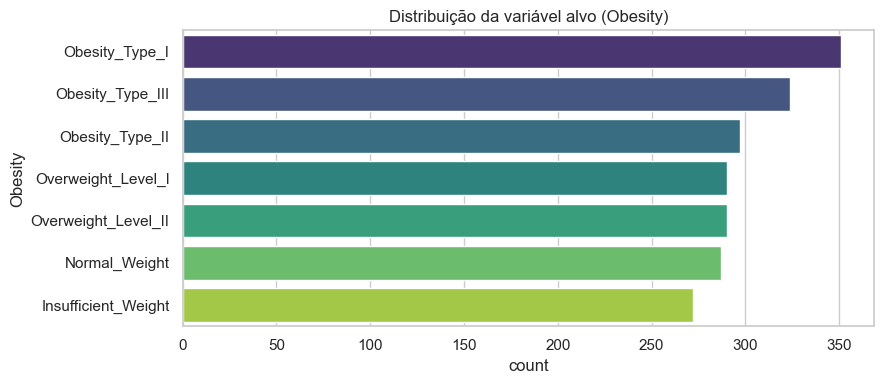

In [6]:
target_counts = df['Obesity'].value_counts()
print(target_counts)

fig, ax = plt.subplots(figsize=(9,4))
sns.countplot(data=df, y='Obesity', order=target_counts.index, ax=ax, palette='viridis')
ax.set_title('Distribuição da variável alvo (Obesity)')
plt.tight_layout()
plt.show()

C:\Users\heitor.mesquita\AppData\Local\Temp\ipykernel_23416\222803397.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Obesity', y='BMI', order=order, ax=ax, palette='coolwarm')


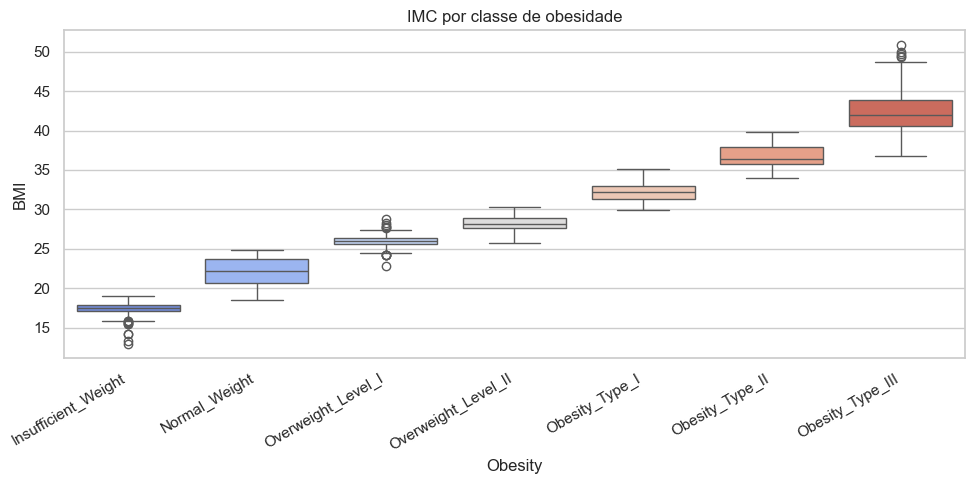

In [7]:
df['BMI'] = df['Weight'] / (df['Height']**2)
order = ['Insufficient_Weight','Normal_Weight','Overweight_Level_I','Overweight_Level_II',
         'Obesity_Type_I','Obesity_Type_II','Obesity_Type_III']
fig, ax = plt.subplots(figsize=(10,5))
sns.boxplot(data=df, x='Obesity', y='BMI', order=order, ax=ax, palette='coolwarm')
ax.set_title('IMC por classe de obesidade')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

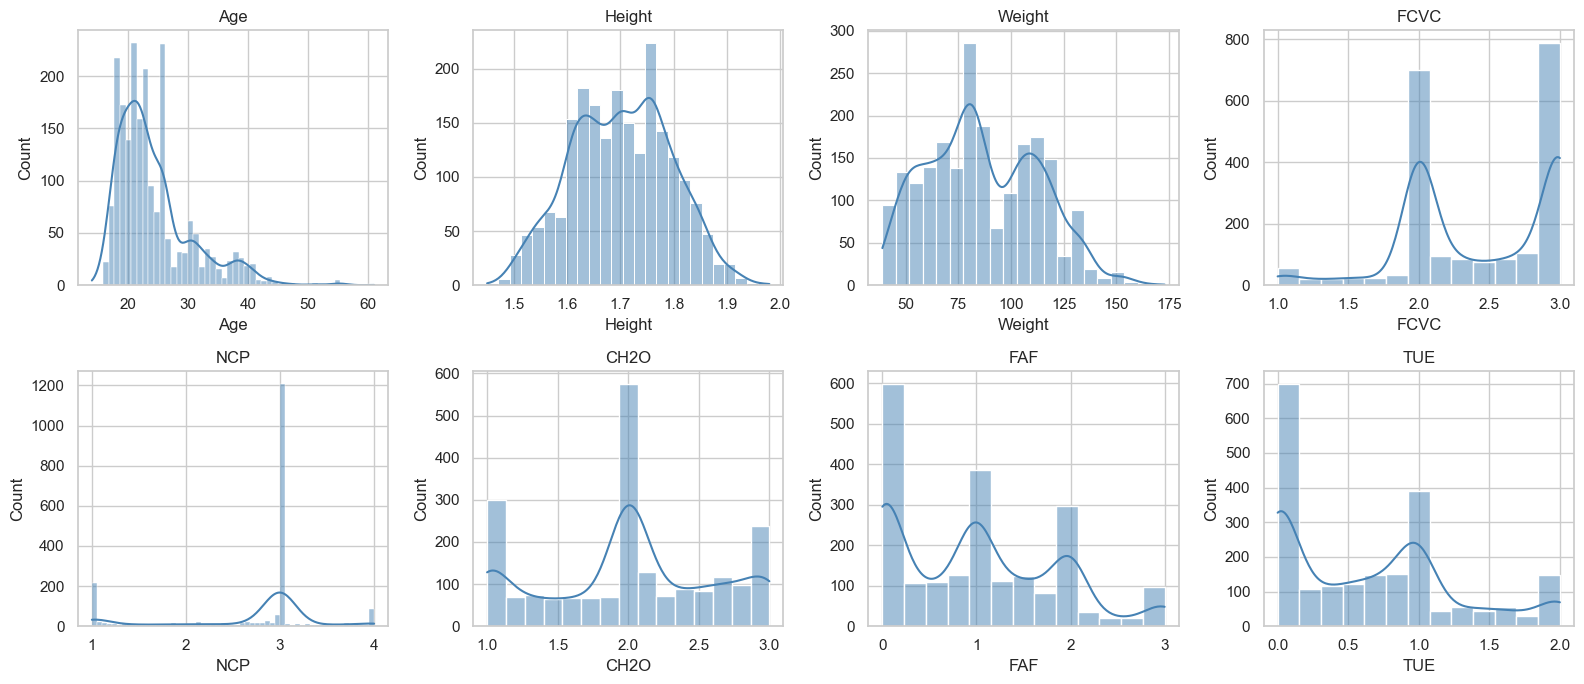

In [8]:
num_cols = ['Age','Height','Weight','FCVC','NCP','CH2O','FAF','TUE']
fig, axes = plt.subplots(2, 4, figsize=(16,7))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(col)
plt.tight_layout()
plt.show()

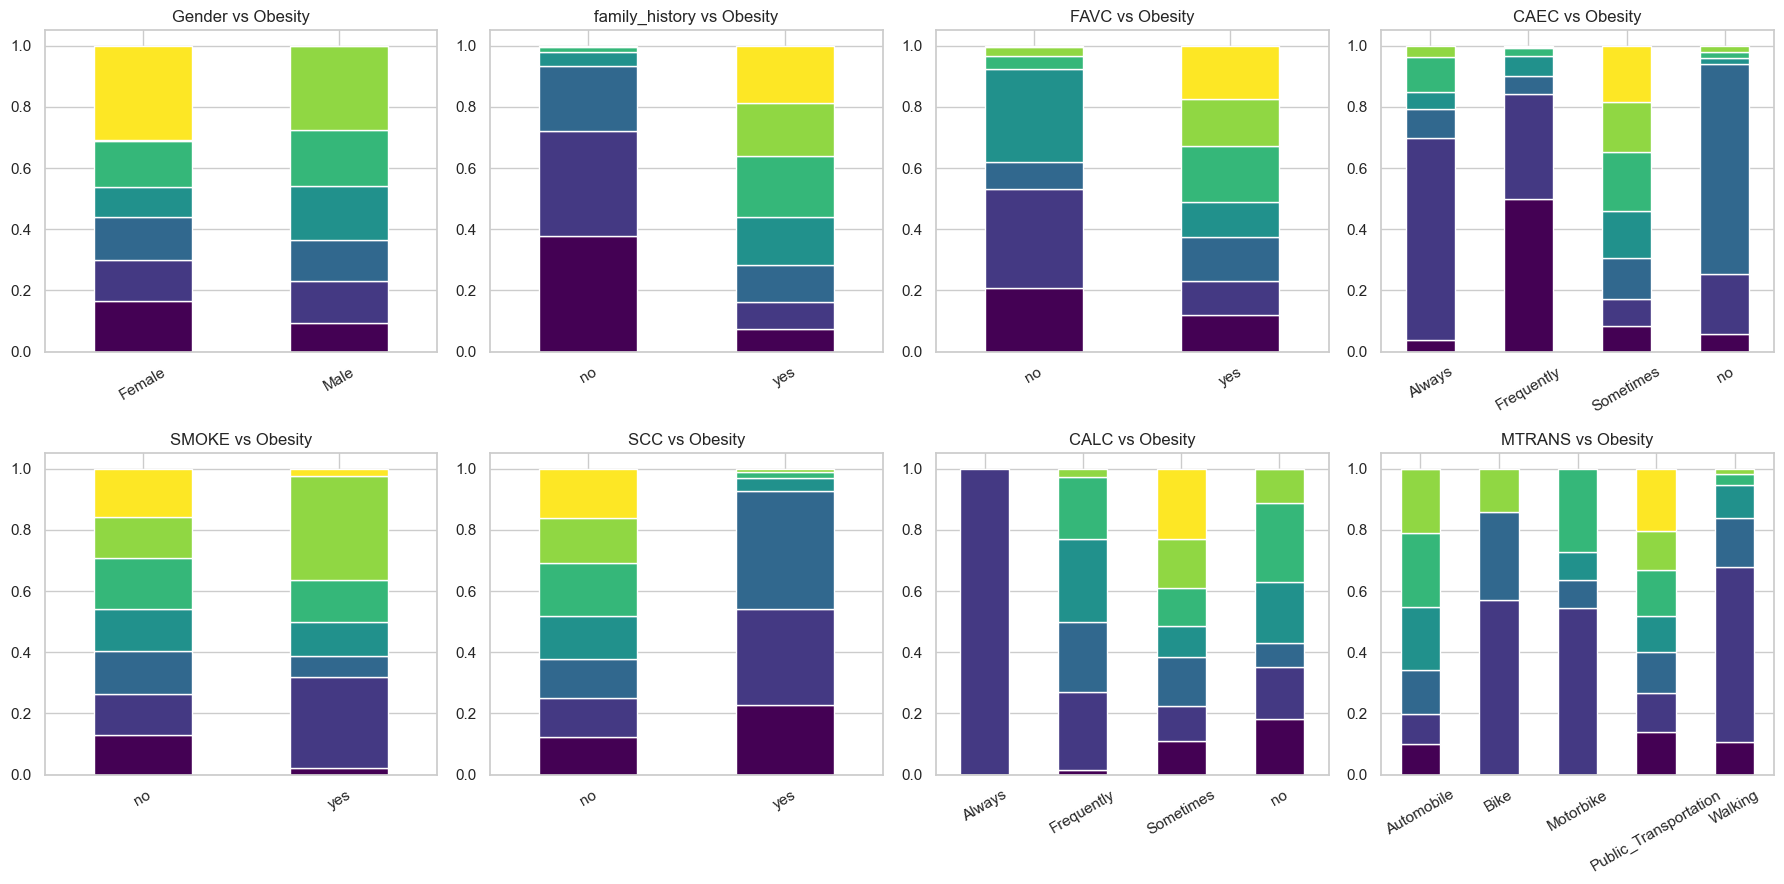

In [9]:
cat_cols = ['Gender','family_history','FAVC','CAEC','SMOKE','SCC','CALC','MTRANS']
fig, axes = plt.subplots(2, 4, figsize=(18,9))
for ax, col in zip(axes.flatten(), cat_cols):
    ct = pd.crosstab(df[col], df['Obesity'], normalize='index')
    ct = ct[order]
    ct.plot(kind='bar', stacked=True, ax=ax, colormap='viridis', legend=False)
    ax.set_title(f'{col} vs Obesity')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

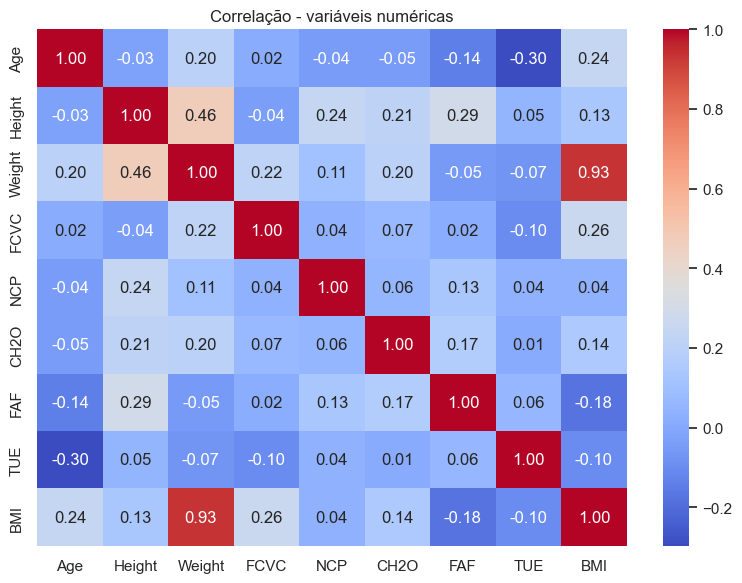

In [10]:
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(df[num_cols + ['BMI']].corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Correlação - variáveis numéricas')
plt.tight_layout()
plt.show()

# 3. Feature Engineering & Pipeline de ML
Arredondar variáveis ordinais com ruído decimal (FCVC, NCP, CH2O, FAF, TUE).
Manter BMI como feature derivada.
One-Hot para categóricas, StandardScaler para numéricas.
Comparar 3 modelos.

In [11]:
data = df.copy()
for c in ['FCVC','NCP','CH2O','FAF','TUE']:
    data[c] = data[c].round().astype(int)

X = data.drop(columns=['Obesity'])
y = data['Obesity']

numeric_features = ['Age','Height','Weight','FCVC','NCP','CH2O','FAF','TUE','BMI']
categorical_features = ['Gender','family_history','FAVC','CAEC','SMOKE','SCC','CALC','MTRANS']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (1688, 17) | Test: (423, 17)


In [12]:
models = {
    'LogReg': LogisticRegression(max_iter=2000),
    'RandomForest': RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingClassifier(random_state=42),
}

results = {}
for name, clf in models.items():
    pipe = Pipeline([('prep', preprocessor), ('clf', clf)])
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
    results[name] = scores
    print(f'{name:20s} acc={scores.mean():.4f} (+/- {scores.std():.4f})')

LogReg               acc=0.9058 (+/- 0.0170)
RandomForest         acc=0.9787 (+/- 0.0071)
GradientBoosting     acc=0.9751 (+/- 0.0048)


In [13]:
best_name = max(results, key=lambda k: results[k].mean())
print('Best model:', best_name)

best_pipe = Pipeline([('prep', preprocessor), ('clf', models[best_name])])
best_pipe.fit(X_train, y_train)

y_pred = best_pipe.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f'\nAcurácia (test): {acc:.4f}')
print('\nClassification report:')
print(classification_report(y_test, y_pred))

Best model: RandomForest

Acurácia (test): 0.9787

Classification report:
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.98      0.99        54
      Normal_Weight       0.90      0.97      0.93        58
     Obesity_Type_I       1.00      1.00      1.00        70
    Obesity_Type_II       0.98      1.00      0.99        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.96      0.93      0.95        58
Overweight_Level_II       1.00      0.98      0.99        58

           accuracy                           0.98       423
          macro avg       0.98      0.98      0.98       423
       weighted avg       0.98      0.98      0.98       423



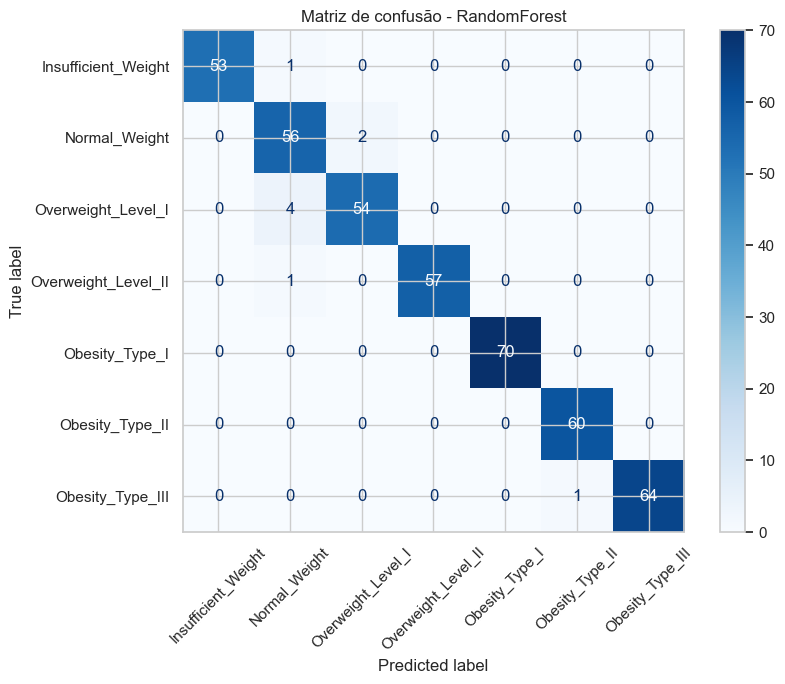

In [14]:
labels = order
fig, ax = plt.subplots(figsize=(9,7))
cm = confusion_matrix(y_test, y_pred, labels=labels)
ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=ax, cmap='Blues', xticks_rotation=45)
ax.set_title(f'Matriz de confusão - {best_name}')
plt.tight_layout()
plt.show()

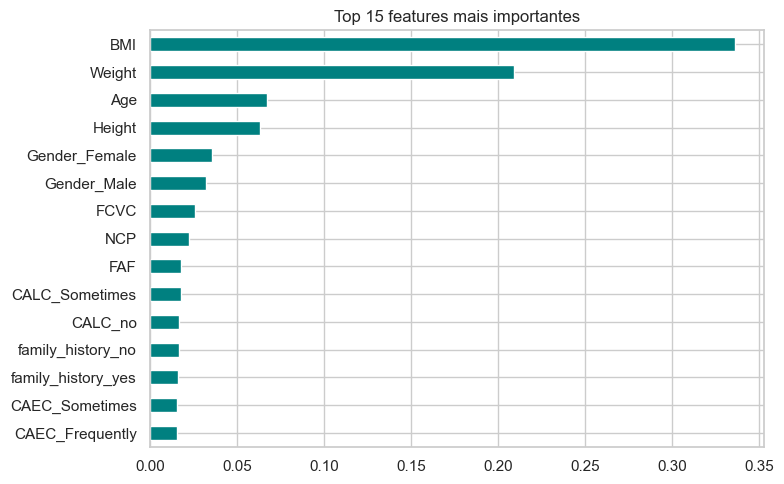

In [15]:
clf_final = best_pipe.named_steps['clf']
if hasattr(clf_final, 'feature_importances_'):
    ohe = best_pipe.named_steps['prep'].named_transformers_['cat']
    feat_names = numeric_features + list(ohe.get_feature_names_out(categorical_features))
    imp = pd.Series(clf_final.feature_importances_, index=feat_names).sort_values(ascending=False).head(15)
    fig, ax = plt.subplots(figsize=(8,5))
    imp.plot(kind='barh', ax=ax, color='teal')
    ax.invert_yaxis()
    ax.set_title('Top 15 features mais importantes')
    plt.tight_layout()
    plt.show()
else:
    print('Modelo não expõe feature_importances_.')

In [16]:
import joblib, os

local_path = 'obesity_model.joblib'
joblib.dump(best_pipe, local_path)
print('Modelo salvo em:', os.path.abspath(local_path))
print('Tamanho:', os.path.getsize(local_path), 'bytes')

Modelo salvo em: c:\Users\heitor.mesquita\OneDrive - Azul Linhas Aéreas\FIAP - Tech Challenge\Fase 4\obesity_model.joblib
Tamanho: 13374682 bytes
